# TS7 - Filtrado digital lineal de ECG 

In [1]:
import numpy as np, scipy.io as sio
from scipy import signal as sig
import matplotlib.pyplot as plt

fs = 1000
mat = sio.loadmat('ecg.mat')
ecg = mat['ecg_lead'].flatten()
N = len(ecg)


# Punto A - Plantilla

Plantilla pasabanda: ripple = 1 dB en banda de paso, atenuación = 20 dB en rechazo.
BW de ECG => **0.5–40 Hz** (TS6)

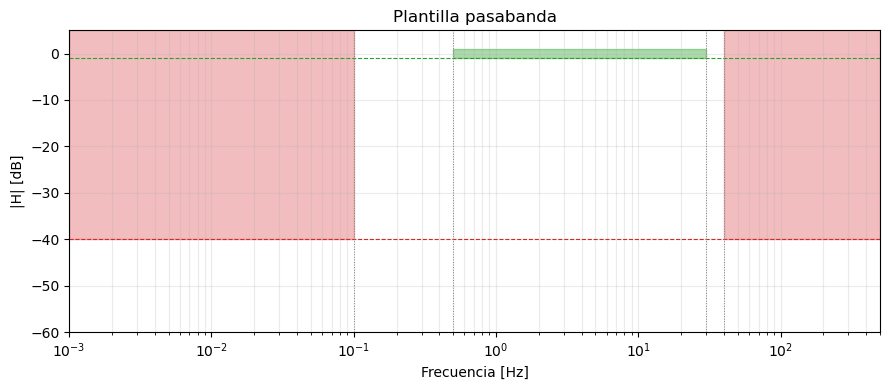

In [2]:
#############
# Plantilla #
#############

nyq_frec   = fs/2
ripple     = 1  # dB
atenuacion = 40 # dB

ws1 = 0.1 # Hz
wp1 = 0.5 # Hz
wp2 = 30  # Hz
ws2 = 40  # Hz


def plot_plantilla(ax):
    # Dibuja la plantilla: rojo = rechazo, verde = banda de paso.
    ax.fill_between([1e-3, ws1],      -atenuacion, 5, color='tab:red',   alpha=.30)
    ax.fill_between([ws2, nyq_frec],  -atenuacion, 5, color='tab:red',   alpha=.30)
    ax.fill_between([wp1, wp2],       -ripple,     1, color='tab:green', alpha=.40)
    ax.axhline(-atenuacion, color='tab:red',   ls='--', lw=.8)
    ax.axhline(-ripple,     color='tab:green', ls='--', lw=.8)
    for e in (ws1, wp1, wp2, ws2):
        ax.axvline(e, color='0.5', ls=':', lw=.7)

# --- utils de ploteo ---
# eje de omega con mas densidad en las transiciones (zonas importantes)
def grilla_w(n_log=2000, n_tr=2000):
    base  = np.logspace(np.log10(1e-3), np.log10(nyq_frec), n_log)
    tr_lo = np.linspace(0.5*ws1, 1.5*wp1, n_tr)   # transicion baja
    tr_hi = np.linspace(0.9*wp2, 1.5*ws2, n_tr)   # transicion alta
    return np.unique(np.concatenate([base, tr_lo, tr_hi]))
w_grid = grilla_w()

def H_db(filtro, fir):
    w, H = (sig.freqz(filtro, worN=w_grid, fs=fs) if fir
            else sig.sosfreqz(filtro, worN=w_grid, fs=fs))
    return w, 20*np.log10(np.abs(H) + 1e-12)

def tam(filtro, fir):  # taps para FIR, orden para IIR (SOS -> *2)
    return f'{len(filtro)} taps' if fir else f'orden {filtro.shape[0]*2}'

def plot_filtro(filtro, fir, nombre):
    fig, (axm, axp) = plt.subplots(2, 1, figsize=(9, 6.5))
    # --- modulo 
    plot_plantilla(axm)
    w, m = H_db(filtro, fir)
    axm.plot(w, m, lw=1.4, color='tab:blue')
    axm.set_xscale('log'); axm.set_xlim(1e-3, nyq_frec); axm.set_ylim(-80, 5)
    axm.set_ylabel('|H| [dB]'); axm.set_xlabel('Frecuencia [Hz]'); axm.grid(True, which='both', alpha=.25)
    axm.set_title(f'{nombre} ({tam(filtro, fir)})')
    
    # --- fase 
    wu, H = (sig.freqz(filtro, worN=16384, fs=fs) if fir
             else sig.sosfreqz(filtro, worN=16384, fs=fs))
    
    axp.plot(wu, np.unwrap(np.angle(H)), lw=1.2, color='tab:orange')
    axp.set_ylabel('fase [rad]'); axp.set_xlabel('Frecuencia [Hz]'); axp.grid(True, alpha=.25)
    axp.set_xlim(0, nyq_frec)
    plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
plot_plantilla(ax)
ax.set_xscale('log'); ax.set_xlim(1e-3, nyq_frec); ax.set_ylim(-60, 5)
ax.set_xlabel('Frecuencia [Hz]'); ax.set_ylabel('|H| [dB]')
ax.set_title('Plantilla pasabanda'); ax.grid(True, which='both', alpha=.25)
plt.tight_layout(); plt.show()

# Punto B

Utilize lo analizado en la TS6, para extraer el ancho de banda de la señal. Para eso, determine que el BW encierre el 98% de la energia total de la señal.

Bajo estas condiciones, el BW de la ECG, dio aproximadamente, entre 0.5 - 30 hz

# Punto C

## Filtros IIR

Los **IIR** (respuesta al impulso infinita) usan muestras de salida anteriores (por ello, su respuesta al impulso no es finita). Cumplen la plantilla con **orden muy bajo**, pero tienen **fase no lineal**, ademas de que pueden ser inestables. Por eso al aplicarlos se suele usar `filtfilt` (ver Punto D).


### Cauer

**Cauer / elíptico:** *equiripple en ambas bandas* (paso y rechazo) -> el **mínimo orden** posible para una plantilla dada. Muy buena transmision (que se paga con fase fuertemente alineal).

orden Cauer: 10


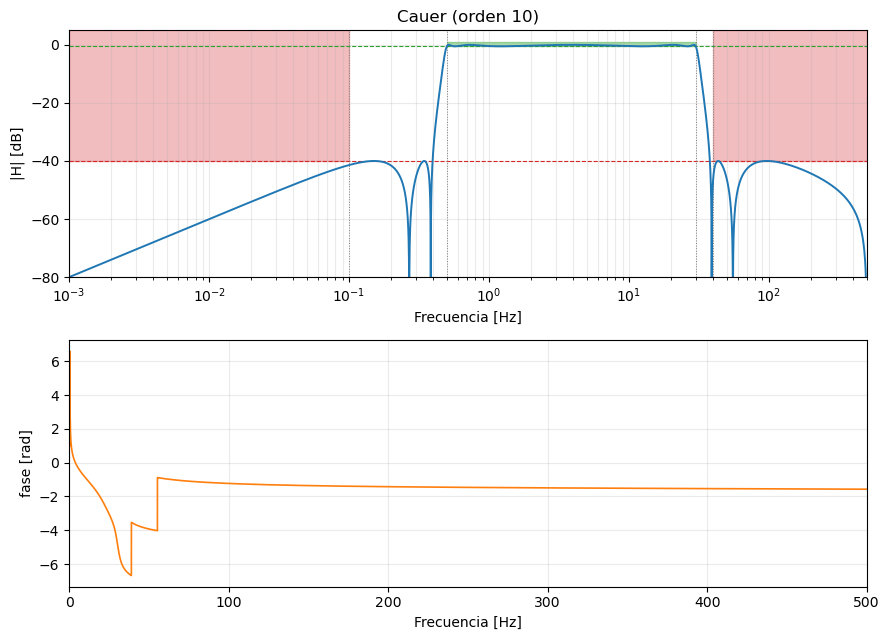

In [3]:
ripple = ripple / 2 # divido por 2, por que despues uso filtfilt
sos_ellip = sig.iirdesign([wp1, wp2], [ws1, ws2], ripple, atenuacion, fs=fs, ftype='ellip', output='sos')
print('orden Cauer:', sos_ellip.shape[0]*2) # Multiplico por 2 por que son SOS
plot_filtro(sos_ellip, False, 'Cauer')

### Butter

**Butterworth:** *maximalmente plano* en la banda de paso y caida monótona. Más suave y predecible, necesita **mas orden** que el Cauer para la misma transicion.

orden Butter: 40


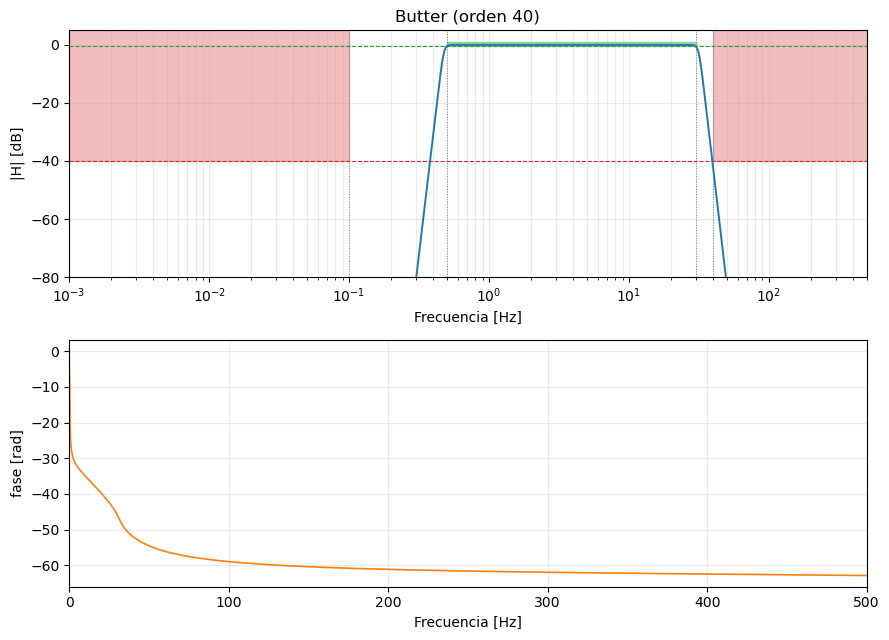

In [4]:
sos_butter = sig.iirdesign([wp1, wp2], [ws1, ws2], ripple, atenuacion, fs=fs, ftype='butter', output='sos')
print('orden Butter:', sos_butter.shape[0]*2) # Multiplico por 2 por que son SOS
plot_filtro(sos_butter, False, 'Butter')

## Filtros FIR

Los **FIR** (respuesta al impulso finita) no tienen realimentacion (solo depende de entradas pasadas), son **siempre estables** y pueden tener **fase lineal exacta** (demora constante). El precio es que necesitan **muchos mas coeficientes** que un IIR.

Este tipo de filtros tiene una fase del tipo:

$$\theta(\omega) = \omega \cdot ((N-1)/2)$$

Por lo que su retardo de grupo, sera $((N-1)/2)$

Sin embargo, algunos tipos de filtros, en concreto el III y IV, agregan tambien una constante de fase, que si bien no aparece en el retardo de grupo, afectan a la señal.
Los filtros fir se pueden dividir en **4 tipos**, segun su **simetria** y su **cantidad de taps**:

| Tipo | Simetria | N (taps) | Ceros fijos | Sirve para |
|------|----------|----------|-------------|------------|
| **I**   | simetrico   | impar | ----- | cualquier cosa |
| **II**  | simetrico                     | par   | cero en **Nyquist** | LP, BP (no HP/BS) |
| **III** | antisimetrico | impar | ceros en **DC y Nyquist** | derivador, Hilbert |
| **IV**  | antisimetrico                 | par   | cero en **DC** | derivador, Hilbert, HP |



### Firwin2

**firwin2:** Utiliza ventaneo para llegar a la plantilla deseada.

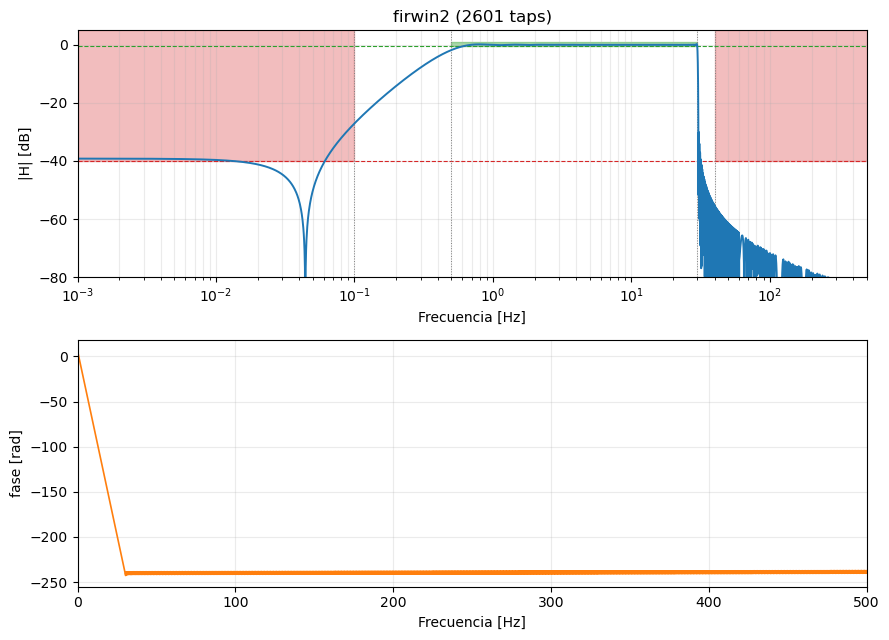

In [18]:
wp11 = 0.5 

desfasaje = 0.3
ws1_d = wp11 - desfasaje
wp1_d = wp11

wp2_d = wp2
ws2_d = wp2 + desfasaje


frecs = np.array([0.0, ws1_d, wp1_d, wp2_d, ws2_d, nyq_frec])
gains = np.array([0,    0,     1,     1,     0,     0])

# FIRWIN2
Nfir = 2601 #Pongo uno impar, asi tambien fuerzo un 0 en nyquist
kaiser_betha_list = [1.6]
for betha in kaiser_betha_list: 
    h_firwin2 = sig.firwin2(Nfir, frecs, gains, window=('kaiser', betha), antisymmetric=False, fs=fs)
    plot_filtro(h_firwin2, True, 'firwin2')

Se observa como, con 2500 taps el firwin logra cumplir con la plantilla, que es bastante exigente, esto con la ayuda del cero topologico que ofrecen los filtros antisimetricos


### Remez

**remez:** optimo *minimax* y **equiripple** con el minimo orden para una tolerancia dada. Teoricamente, puede conseguir filtros de menor orden para una misma selectividad, Pero no asegura convergencia (es iterativo)

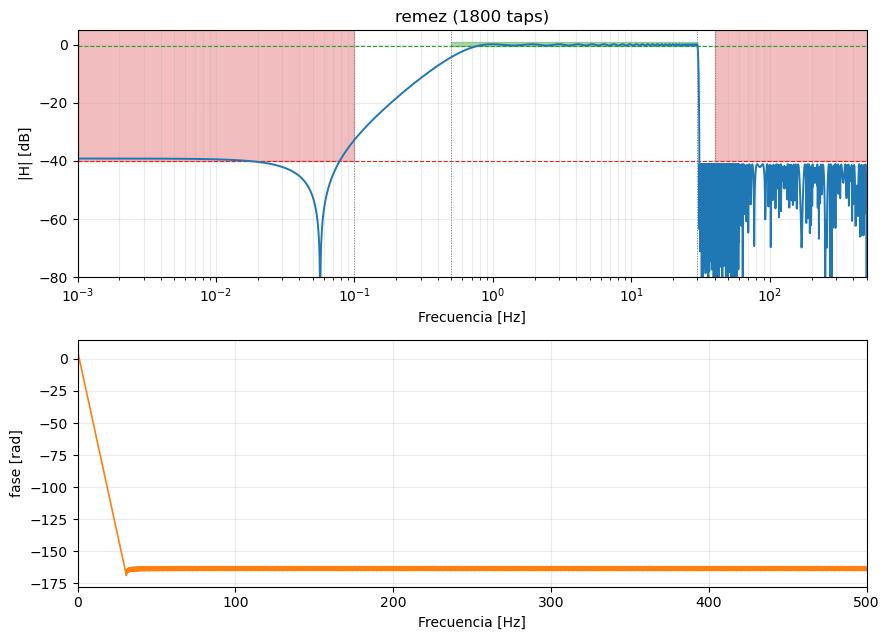

In [6]:
#####
wp11 = 1 # Parece que le estoy sacando ancho de banda, pero el filtro con este valor de MUY bien y dentro del orden esperado

desfasaje = 0.95

ws1_d = wp11 - desfasaje
wp1_d = wp11

wp2_d = wp2
ws2_d = wp2 + desfasaje


Nremez = 1800

h_remez = sig.remez(Nremez
                    , [0, ws1_d, wp1_d, wp2_d, ws2_d, nyq_frec]
                    , [0, 1, 0]
                    , weight=[16, 7, 20]
                    , fs=fs
                    ,grid_density= 32
                   )
plot_filtro(h_remez, True, 'remez')

## Plotteos finales
Módulo de los IIR y los FIR sobre la plantilla.

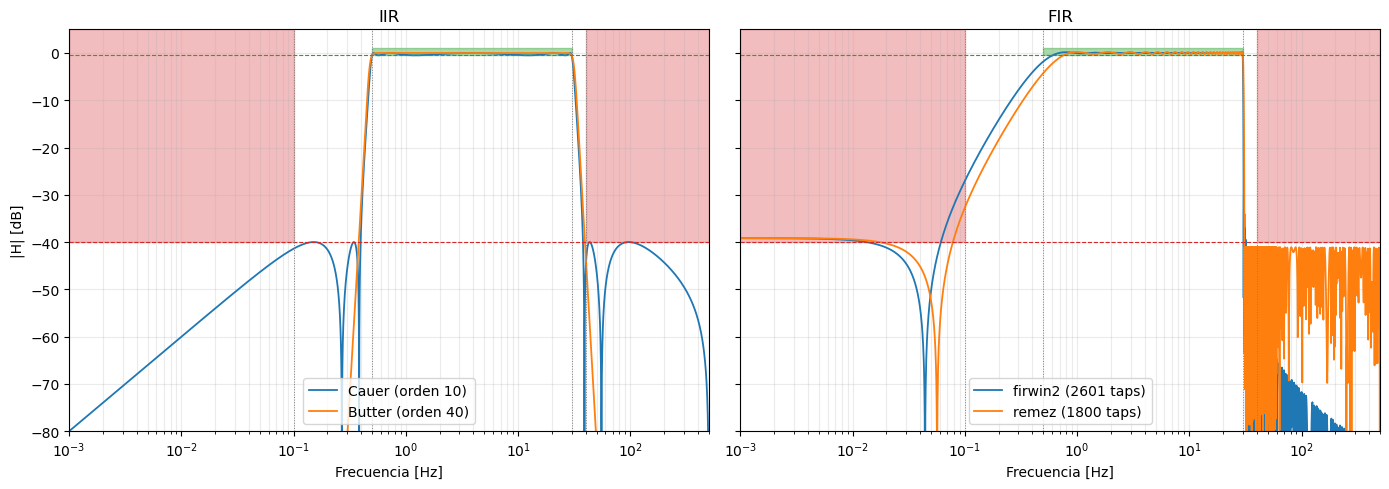

In [7]:
fig, (ax_iir, ax_fir) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for sos, nombre in [(sos_ellip, 'Cauer'), (sos_butter, 'Butter')]:
    w, m = H_db(sos, fir=False)
    ax_iir.plot(w, m, lw=1.3, label=f'{nombre} ({tam(sos, False)})')

for h, nombre in [(h_firwin2, 'firwin2'), (h_remez, 'remez')]:
    w, m = H_db(h, fir=True)
    ax_fir.plot(w, m, lw=1.3, label=f'{nombre} ({tam(h, True)})')

for ax, titulo in [(ax_iir, 'IIR'), (ax_fir, 'FIR')]:
    plot_plantilla(ax)
    ax.set_xscale('log'); ax.set_xlim(1e-3, nyq_frec); ax.set_ylim(-80, 5)
    ax.grid(True, which='both', alpha=.25); ax.legend(loc='lower center')
    ax.set_xlabel('Frecuencia [Hz]'); ax.set_title(titulo)
ax_iir.set_ylabel('|H| [dB]')
plt.tight_layout(); plt.show()

# Punto D - Aplicacion a la señal

Aplico los filtros a la señal y verifico que:
**(1)** filtran las interferencias (zonas con ruido)
**(2)** son **inocuos** donde no hay interferencia (zonas limpias).

**Como compenso la demora en filtros?**
- **A) `lfilter` + compensar a mano:** la salida sale corrida `(N-1)//2` muestras (demora de un fir) se realinea leyendo `ECG[z + demora]`.
- **B) `filtfilt`:** filtra **dos veces, invirtiendo la señal**. Las demoras se can celan entre si -> **fase cero automaticamente**. filtra dos veces -> la respuesta efectiva es $|H|^2$ y es **no causal** (necesita toda la señal para poder invertirla, no se puede hacer en tiempo real).


En general, los filtros fir como tienen fase lineal, se acostumbra a usarlos con `lfilter`, ya que corregir su retardo de grupo es muy sencillo. en los IIR, es mucho mas comun el uso de `filtfilt`


In [8]:
cant_muestras = len(ecg)

# IIR -> filtfilt (fase cero, sin demora)
ECG_cauer  = sig.sosfiltfilt(sos_ellip,  ecg)
ECG_butter = sig.sosfiltfilt(sos_butter, ecg)

# remez y firwin son SIMETRICOS -> lfilter + compensar la demora (N-1)//2
ECG_firwin2 = sig.lfilter(h_firwin2, 1, ecg);  dem_firwin = (len(h_firwin2) - 1)//2
ECG_remez = sig.lfilter(h_remez, 1, ecg);  dem_remez = (len(h_remez) - 1)//2

def plot_regiones(regs, titulo):
    for ii in regs:
        z = np.arange(int(ii[0]), min(int(ii[1]), cant_muestras - dem_remez))
        plt.figure(figsize=(12, 4))
        plt.plot(z, ecg[z], 'k',              label='ECG original', lw=2, alpha=.4)
        plt.plot(z, ECG_cauer[z],             label='Cauer (IIR)')
        plt.plot(z, ECG_butter[z],             label='Butter (IIR)')
        plt.plot(z, ECG_firwin2[z + dem_firwin],           label='firwin2 (FIR)')
        plt.plot(z, ECG_remez[z + dem_remez], label='remez (FIR)')
        plt.title(f'{titulo}  [{int(ii[0])} - {int(ii[1])}]')
        plt.xlabel('Muestras'); plt.gca().set_yticks(()); plt.legend()
        plt.tight_layout(); plt.show()

## 1) Zonas CON ruido

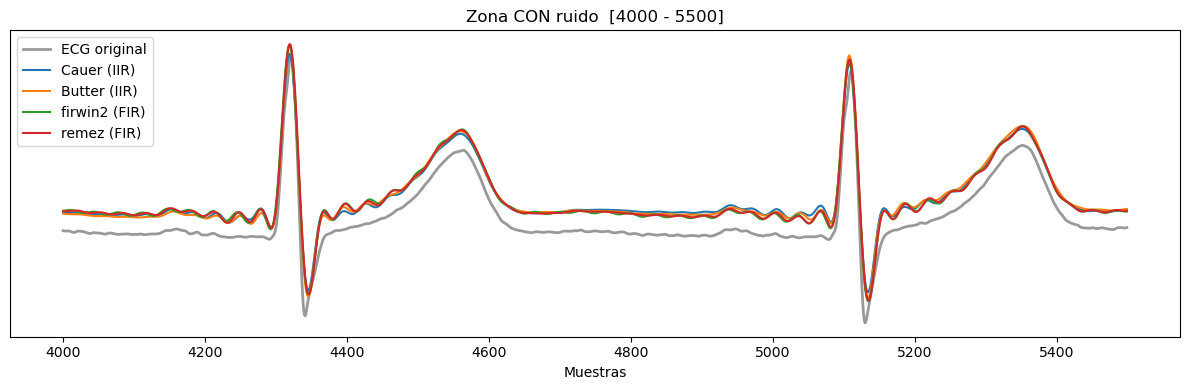

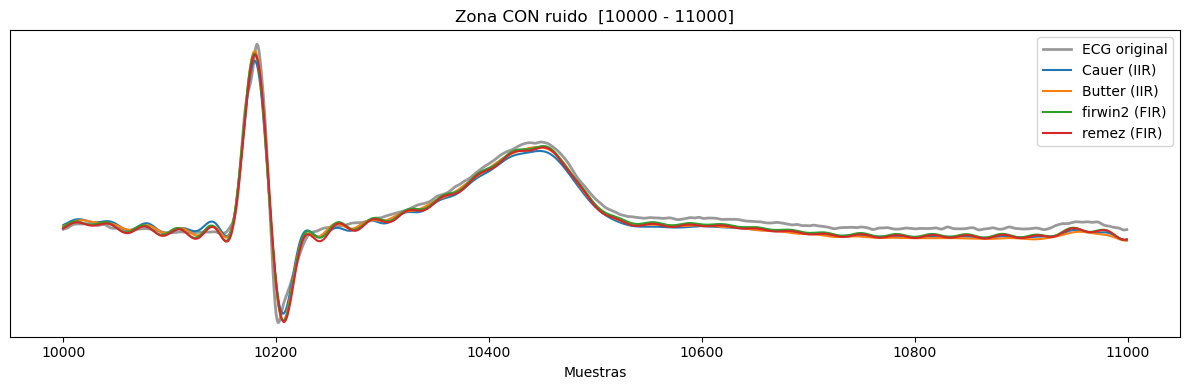

In [9]:
regs_ruido = ([4000, 5500], [10000, 11000])
plot_regiones(regs_ruido, 'Zona CON ruido')

## 2) Zonas SIN ruido

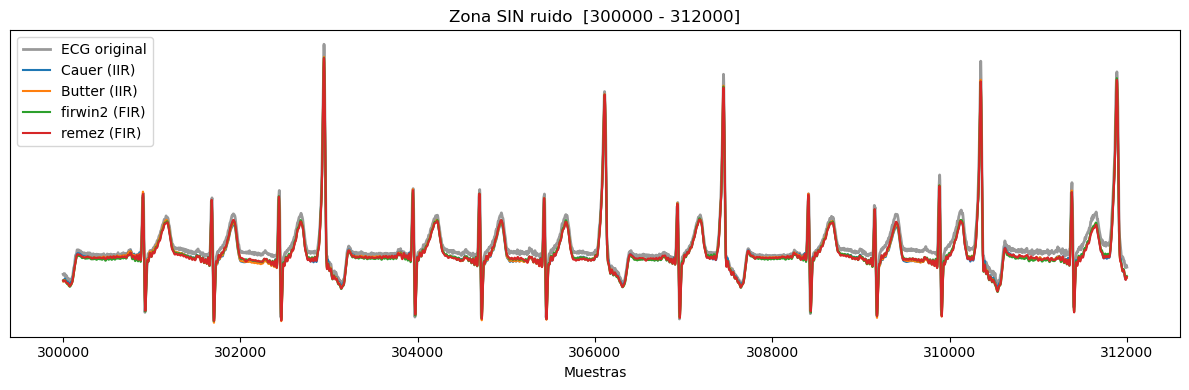

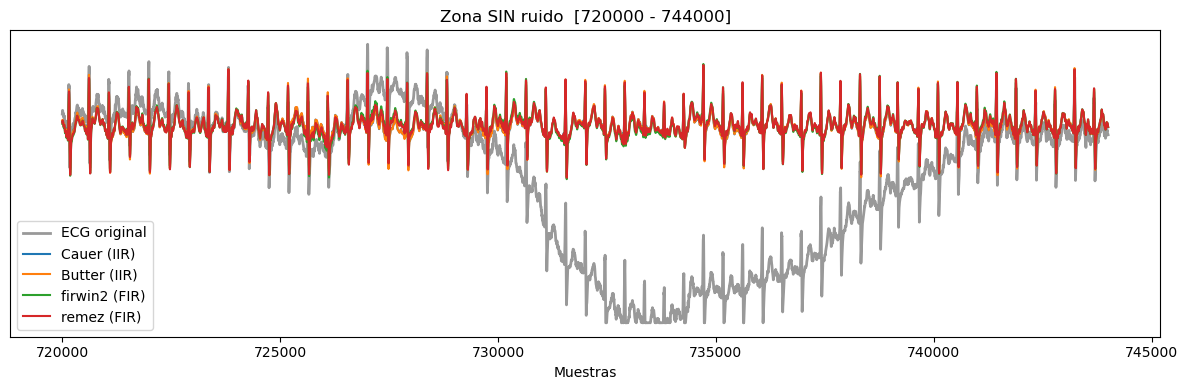

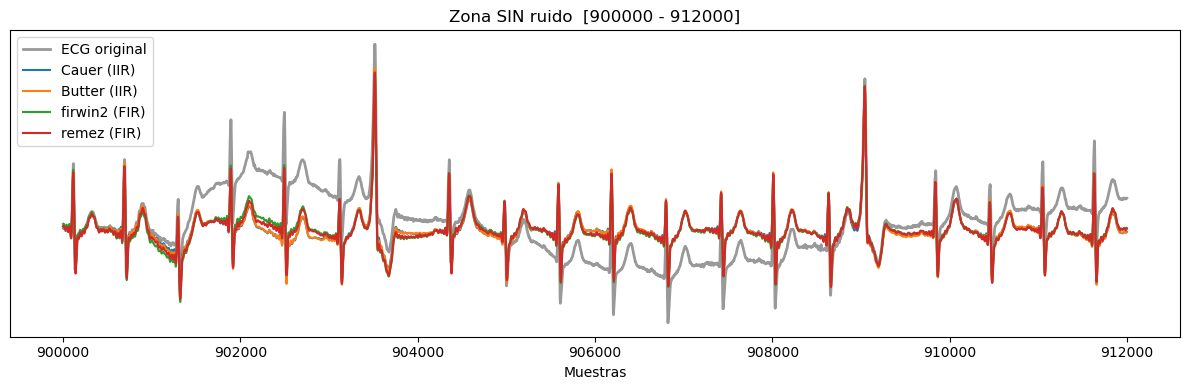

In [10]:
regs_limpio = (np.array([5, 5.2]) * 60 * fs,     # min -> muestras
               np.array([12, 12.4]) * 60 * fs,
               np.array([15, 15.2]) * 60 * fs)
plot_regiones(regs_limpio, 'Zona SIN ruido')

Se observa como, en todos los casos, la señal sigue fielmente a la original, los pulsos "R" estan perfectamente alineados entre si (esto ya que corregimos los errores de fase con filtfilt / restando demora) y se observa como, las componentes de baja frecuencia estan claramente elimionadas (sobre todo en la zona de 720000 - 744000) que es justamente lo esperado.

Adicionalmente, se observa en las zonas con ruido, como la distorsion de la señal fue minima. Claramente, los filtros IIR (sobre todo el de maxima planicidad) es el que mejor mantiene la forma original de la señal, pero a costas de sacrificar estabilidad y respuesta en tiempo real.


algo importante a destacar, es que en un primer momento, los filtros antisimetricos, parecian una opcion mujy tentadora a la hora de diseñar los filtros. Sin embargo, el cero topologico en continua, provocaba que la fase tuviera una constante sumada. Esto mismo, provocaba distorsiones de fase en la señal (a pesar de que las mismas no se reflejaran en el retardo de grupo). Este efecto, puede observarse a continuacion brevemente

## Consecuencias de constante en fase

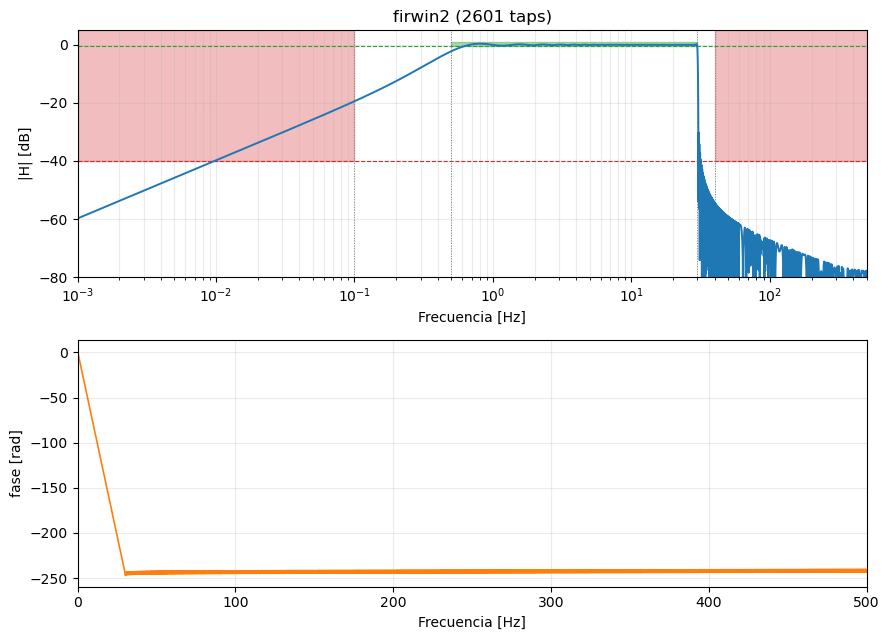

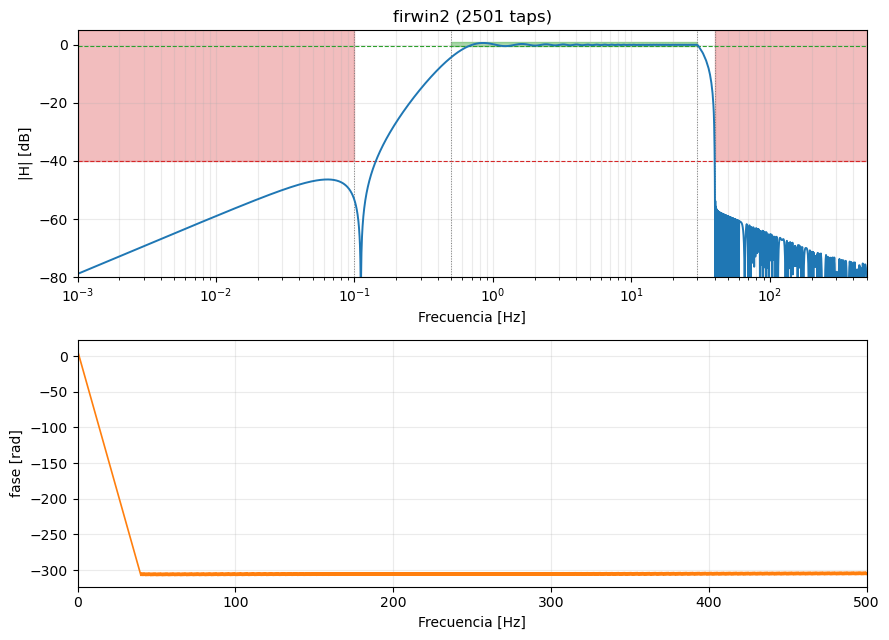

In [21]:
# pre-distorsion de plantilla
ws1_d = 0.4
wp1_d = 0.5
wp2_d = wp2 * 1
ws2_d = 40

frecs = np.array([0.0, ws1_d, wp1_d, wp2_d, ws2_d, nyq_frec])
gains = np.array([0,    0,     1,     1,     0,     0])

# FIRWIN2
Nfir = 2501 #Pongo uno impar, asi tambien fuerzo un 0 en nyquist
kaiser_list = [1.2]
for betha in kaiser_list: 
    h_firwin2_antisymetric = sig.firwin2(Nfir, frecs, gains, window=('kaiser', betha), antisymmetric=True, fs=fs)
    plot_filtro(h_firwin2_antisymetric, True, 'firwin2')

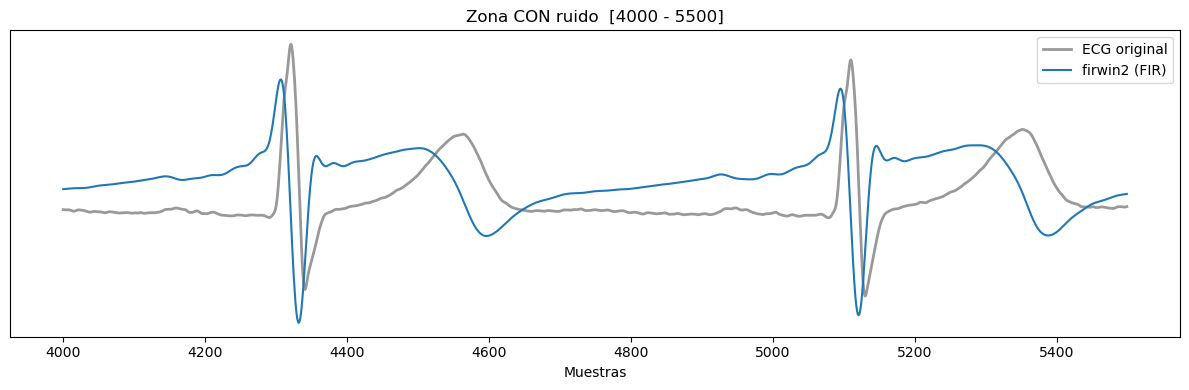

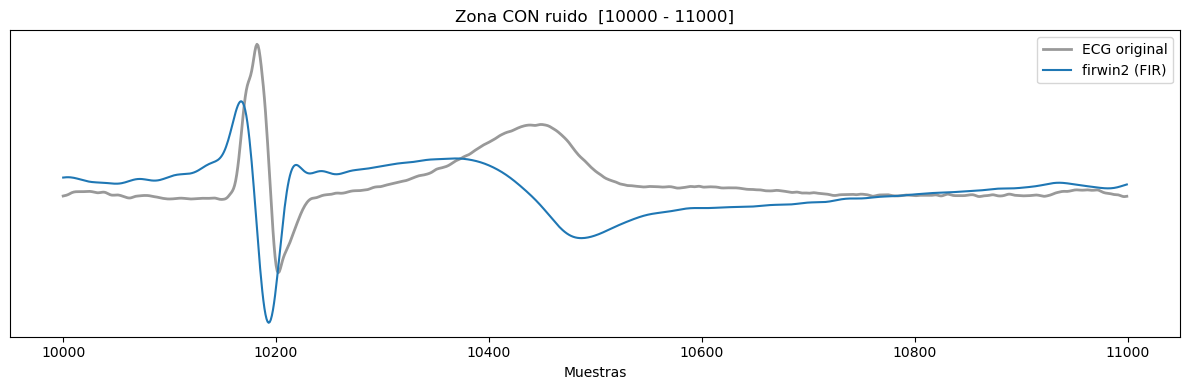

In [23]:
cant_muestras = len(ecg)


# firwin2 es ANTISIMETRICO
ECG_firwin2_antisym = sig.lfilter(h_firwin2_antisymetric, 1, ecg);  dem_firwin = (len(h_firwin2_antisymetric) - 1)//2

def plot_regiones(regs, titulo):
    for ii in regs:
        z = np.arange(int(ii[0]), min(int(ii[1]), cant_muestras - dem_remez))
        plt.figure(figsize=(12, 4))
        plt.plot(z, ecg[z], 'k',              label='ECG original', lw=2, alpha=.4)
        plt.plot(z, ECG_firwin2_antisym[z + dem_firwin],           label='firwin2 (FIR)')
        plt.title(f'{titulo}  [{int(ii[0])} - {int(ii[1])}]')
        plt.xlabel('Muestras'); plt.gca().set_yticks(()); plt.legend()
        plt.tight_layout(); plt.show()

regs_ruido = ([4000, 5500], [10000, 11000])
plot_regiones(regs_ruido, 'Zona CON ruido')

Se observa que la señal no sólo está claramente desfasada respecto de la original (se ve en los picos R), a pesar de haber corregido el retardo de grupo, sino que además aparece **deformada** en ciertas partes, producto de la alteración de fase.

Esto sucede porque al desfasar una senoidal por una fase $\theta$, el corrimiento temporal resultante depende de su **frecuencia**:

$$\sin(\omega x + \theta) = \sin\!\Big(\omega \cdot x + \theta\Big)$$

$$\sin(\omega x + \theta) = \sin\!\Big(\omega\big(x + \tfrac{\theta}{\omega}\big)\Big)$$

es decir, el retardo temporal (retardo de fase) es $\tau_\phi = \theta/\omega$.

Si $\theta$ es **linealmente dependiente** de $\omega$ ($\theta = \omega\,k$), entonces $\tau_\phi = k$ es **igual para todas las frecuencias**. osea qeu todas se atrasan lo mismo y la forma de onda se conserva (solo se traslada). En cambio, una **constante** sumada a $\theta$ hace que $\tau_\phi = k + \tfrac{\theta_0}{\omega}$ dependa de la frecuencia, rompiendo el atraso uniforme de esta forma cada componente se corre un tiempo distinto y la señal se deforma.

Por eso, aunque una constante en la fase **no altera el retardo de grupo** ($\tau_g = -d\theta/d\omega$, donde la constante desaparece al derivar), **sí altera el retardo de fase** y puede deformar la señal. En el caso del filtro antisimétrico, esa constante vale $\pi/2$, cuyo efecto sobre cada componente equivale a una transformada de Hilbert.